# Parte 3 - Análisis Exploratorio de Datos (EDA)

## Objetivo del análisis
El objetivo de esta etapa es explorar el catálogo de StreamView Analytics para
identificar patrones, tendencias y oportunidades relevantes para la Gerencia
de Contenidos y Adquisición.

El análisis se enfocará en comprender:

- La composición actual del catálogo.
- El desempeño de los contenidos según género, país y otras características.
- La relación entre popularidad, valoración e interacción.
- La evolución temporal del catálogo.
- El comportamiento financiero de las películas.

## 1. Composición del catálogo

Antes de analizar el desempeño de los contenidos, es necesario comprender
cómo está compuesto el catálogo de StreamView Analytics.

En esta sección se analizará la distribución de los contenidos según:

- Tipo de contenido.
- Género.
- País de origen.
- Clasificación por edad.

Este análisis permitirá identificar qué categorías concentran una mayor
presencia dentro del catálogo y establecer una base para los análisis
posteriores.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("streamview_catalogo_limpio.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue,date_added_year,roi
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,Sin información,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0,2010,4.561217
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,Sin información,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0,2010,5.243941
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,Sin información,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0,2010,3.817223
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,Sin información,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000.0,592461732.0,2010,2.278699
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,Sin información,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000.0,494879471.0,2010,2.999270


In [ ]:
print("Cantidad de registros:", df.shape[0])
print("Cantidad de variables:", df.shape[1])

df.info()

Cantidad de registros: 31594
Cantidad de variables: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31594 entries, 0 to 31593
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   show_id          31594 non-null  int64  
 1   type             31594 non-null  object 
 2   title            31594 non-null  object 
 3   director         31594 non-null  object 
 4   cast             31594 non-null  object 
 5   country          31594 non-null  object 
 6   date_added       31594 non-null  object 
 7   release_year     31594 non-null  int64  
 8   rating           31594 non-null  float64
 9   duration         31594 non-null  object 
 10  genres           31594 non-null  object 
 11  language         31594 non-null  object 
 12  description      28324 non-null  object 
 13  popularity       31594 non-null  float64
 14  vote_count       31594 non-null  int64  
 15  vote_average     31594 non-null  float64
 16  bud

### 1.1 Distribución por tipo de contenido

La primera exploración busca conocer cómo se distribuye el catálogo entre
películas y series.

Esta información permite comprender la estructura general de la oferta de
StreamView Analytics antes de analizar otras características del contenido.

In [ ]:
tipo_contenido = df["type"].value_counts()

tipo_contenido

,count
type,
Movie,16000
TV Show,15594


In [ ]:
tipo_porcentaje = df["type"].value_counts(normalize=True) * 100

tipo_porcentaje

,proportion
type,
Movie,50.642527
TV Show,49.357473


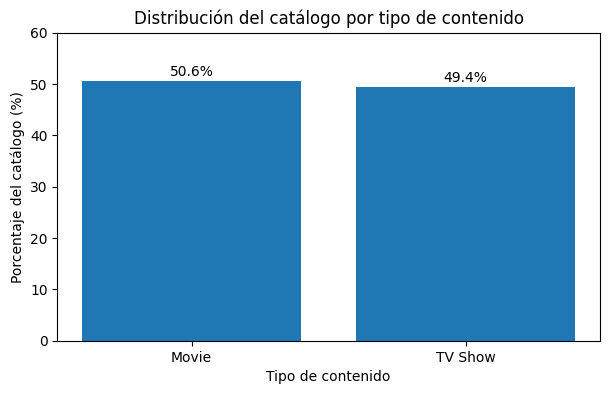

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

barras = ax.bar(
    tipo_porcentaje.index,
    tipo_porcentaje.values
)

ax.set_title("Distribución del catálogo por tipo de contenido")
ax.set_ylabel("Porcentaje del catálogo (%)")
ax.set_xlabel("Tipo de contenido")
ax.set_ylim(0, 60)

# Mostrar el porcentaje sobre cada barra
for barra in barras:
    valor = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras porque permite comparar directamente la
cantidad relativa de las dos categorías de contenido.

Aunque existen solamente dos categorías, la diferencia entre ambas es
pequeña, por lo que la longitud de las barras facilita una comparación más
precisa que una representación basada en ángulos o áreas.

El eje vertical comienza en cero para evitar exagerar visualmente las
diferencias entre películas y series.

**Hallazgo:**

El catálogo presenta una distribución prácticamente equilibrada entre películas
y series. Las películas representan el 50,64 % del catálogo, mientras que las
series corresponden al 49,36 %.

La diferencia entre ambos tipos de contenido es reducida, por lo que no se
observa una predominancia significativa de uno sobre el otro en términos de
cantidad de títulos.


**Interpretación:**

Este resultado describe únicamente la composición del catálogo. No permite
concluir que películas y series tengan el mismo nivel de popularidad,
valoración o desempeño.

Estas diferencias deberán analizarse posteriormente utilizando variables
como `popularity`, `vote_average` y `vote_count`.



---



### 1.2 Distribución por género

En esta sección se analiza la composición del catálogo según género.

Debido a que un mismo contenido puede estar asociado a más de un género,
es necesario separar los valores contenidos en la variable `genres` antes
de realizar el conteo.

El objetivo es identificar qué géneros concentran una mayor cantidad de
títulos dentro del catálogo.

In [ ]:
df["genres"].head(10)

,genres
0,"Comedy, Adventure, Fantasy, Animation, Family"
1,"Action, Science Fiction, Adventure"
2,"Adventure, Fantasy"
3,"Animation, Family, Adventure"
4,"Fantasy, Adventure, Animation, Family"
5,"Drama, Thriller, Mystery"
6,"Action, Adventure, Drama, Family"
7,"Adventure, Action, Science Fiction"
8,Comedy
9,"Drama, Romance"


In [ ]:
df["genres"].dropna().sample(10)

,genres
26769,"Crime, Drama"
2785,Drama
30137,Drama
19965,Drama
31350,Drama
20092,"Crime, Reality"
3983,Drama
21628,Documentary
8419,"Romance, TV Movie"
7145,"Drama, Fantasy, Mystery, Romance"


In [ ]:
df_generos = df.assign(
    genre=df["genres"].str.split(",")
).explode("genre")

df_generos["genre"] = df_generos["genre"].str.strip()

df_generos[["title", "genres", "genre"]].head(15)

,title,genres,genre
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Comedy
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Adventure
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Fantasy
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Animation
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Family
1,Inception,"Action, Science Fiction, Adventure",Action
1,Inception,"Action, Science Fiction, Adventure",Science Fiction
1,Inception,"Action, Science Fiction, Adventure",Adventure
2,Harry Potter and the Deathly Hallows: Part 1,"Adventure, Fantasy",Adventure
2,Harry Potter and the Deathly Hallows: Part 1,"Adventure, Fantasy",Fantasy


In [ ]:
generos_conteo = df_generos["genre"].value_counts()

generos_conteo

,count
genre,
Drama,14575
Comedy,8984
Animation,4001
Thriller,3769
Action,3239
Crime,3168
Family,2967
Romance,2571
Mystery,2556


In [ ]:
print("Cantidad de géneros diferentes:", df_generos["genre"].nunique())
print("Total de asociaciones contenido-género:", df_generos["genre"].count())

Cantidad de géneros diferentes: 29
Total de asociaciones contenido-género: 66245


#### Estandarización de las categorías de género

Durante la exploración de la variable `genres` se identificaron diferencias
en la forma en que algunos géneros se encuentran representados.

Por ejemplo, existen categorías compuestas como `Action & Adventure` y
`Sci-Fi & Fantasy`, mientras que en otros registros estos conceptos aparecen
como géneros separados (`Action`, `Adventure`, `Science Fiction` y `Fantasy`).

También se identificaron dos formas de representar la ausencia de información:
`Unknown` y `Sin información`.

Para evitar que estas diferencias de nomenclatura distorsionen el análisis,
se estandarizarán estas categorías antes de calcular la distribución final
de géneros.

In [ ]:
# Reemplazar categorías compuestas por géneros separados
df_generos["genre"] = df_generos["genre"].replace({
    "Action & Adventure": "Action|Adventure",
    "Sci-Fi & Fantasy": "Science Fiction|Fantasy",
    "Unknown": "Sin información"
})

# Separar nuevamente las categorías que acabamos de combinar con |
df_generos["genre"] = df_generos["genre"].str.split("|")

# Crear una fila por cada género
df_generos = df_generos.explode("genre")

# Eliminar posibles espacios
df_generos["genre"] = df_generos["genre"].str.strip()

In [ ]:
generos_conteo = df_generos["genre"].value_counts()

generos_conteo

,count
genre,
Drama,14575
Comedy,8984
Action,5174
Animation,4001
Thriller,3769
Adventure,3703
Science Fiction,3363
Fantasy,3359
Crime,3168


In [ ]:
print("Cantidad de géneros después de estandarizar:",
      df_generos["genre"].nunique())

Cantidad de géneros después de estandarizar: 26


#### Selección de categorías para la visualización

Luego de estandarizar las categorías se identificaron 26 géneros diferentes.

Para facilitar la lectura y reducir la carga cognitiva, la visualización se
centrará en los 10 géneros con mayor cantidad de asociaciones dentro del
catálogo.

Las categorías restantes se conservan en el análisis, pero no se incluyen en
esta visualización debido a su menor frecuencia.

In [ ]:
top_10_generos = generos_conteo.head(10)

top_10_generos

,count
genre,
Drama,14575
Comedy,8984
Action,5174
Animation,4001
Thriller,3769
Adventure,3703
Science Fiction,3363
Fantasy,3359
Crime,3168


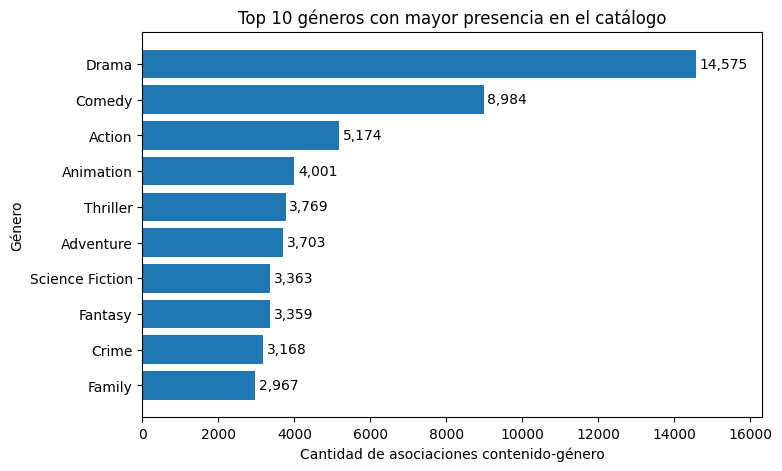

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_10_generos.index[::-1],
    top_10_generos.values[::-1]
)

ax.set_title("Top 10 géneros con mayor presencia en el catálogo")
ax.set_xlabel("Cantidad de asociaciones contenido-género")
ax.set_ylabel("Género")

ax.set_xlim(0, top_10_generos.max() * 1.12)

for barra in barras:
    valor = barra.get_width()
    ax.text(
        valor + 100,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales porque permite comparar de forma
clara la frecuencia de múltiples categorías y facilita la lectura de los
nombres de los géneros.

La visualización se limita a los 10 géneros con mayor presencia para evitar
sobrecargar el gráfico con categorías de baja frecuencia y favorecer una
interpretación rápida de las diferencias entre ellas.

**Hallazgo:**

Drama es el género con mayor presencia dentro del catálogo, con 14.575
asociaciones, seguido por Comedy con 8.984.

A partir del tercer lugar se observa una disminución importante en la cantidad
de asociaciones. Action registra 5.174, mientras que Animation, Thriller,
Adventure, Science Fiction y Fantasy presentan valores cercanos entre sí.

Esto indica que la composición del catálogo se encuentra fuertemente
concentrada en contenidos asociados a Drama y, en menor medida, Comedy.

**Interpretación:**

La mayor presencia de Drama y Comedy describe la composición actual del
catálogo, pero no implica que estos géneros tengan necesariamente un mejor
desempeño.

Para evaluar su rendimiento será necesario cruzar posteriormente los géneros
con variables como `popularity`, `vote_average` y `vote_count`.

### 1.3 Distribución por país de origen

En esta sección se analiza la composición del catálogo según el país de origen
de los contenidos.

Debido a que algunos títulos pueden estar asociados a más de un país, primero
se revisará la estructura de la variable `country` antes de realizar el conteo.

El objetivo es identificar qué países concentran una mayor presencia dentro
del catálogo de StreamView Analytics.

In [ ]:
df["country"].head(10)

,country
0,United States of America
1,"United Kingdom, United States of America"
2,"United Kingdom, United States of America"
3,United States of America
4,United States of America
5,United States of America
6,"China, Hong Kong, United States of America"
7,United States of America
8,United States of America
9,"France, Spain"


In [ ]:
df["country"].dropna().sample(10)

,country
16783,Mexico
11743,United States of America
12818,"South Africa, United States of America"
8365,United States of America
16946,France
19020,Chile
2234,United States of America
17058,Japan
6079,"United States of America, Bulgaria"
2129,United Kingdom


In [ ]:
df_paises = df.assign(
    country_individual=df["country"].str.split(",")
).explode("country_individual")

df_paises["country_individual"] = (
    df_paises["country_individual"].str.strip()
)

df_paises[["title", "country", "country_individual"]].head(15)

,title,country,country_individual
0,Shrek Forever After,United States of America,United States of America
1,Inception,"United Kingdom, United States of America",United Kingdom
1,Inception,"United Kingdom, United States of America",United States of America
2,Harry Potter and the Deathly Hallows: Part 1,"United Kingdom, United States of America",United Kingdom
2,Harry Potter and the Deathly Hallows: Part 1,"United Kingdom, United States of America",United States of America
3,Tangled,United States of America,United States of America
4,How to Train Your Dragon,United States of America,United States of America
5,Shutter Island,United States of America,United States of America
6,The Karate Kid,"China, Hong Kong, United States of America",China
6,The Karate Kid,"China, Hong Kong, United States of America",Hong Kong


In [ ]:
paises_conteo = df_paises["country_individual"].value_counts()

paises_conteo

,count
country_individual,
United States of America,10874
Japan,2822
United Kingdom,2583
China,2369
Sin información,2217
...,...
Palau,1
Brunei Darussalam,1
Fiji,1


In [ ]:
print(
    "Cantidad de países/categorías diferentes:",
    df_paises["country_individual"].nunique()
)

print(
    "Total de asociaciones contenido-país:",
    df_paises["country_individual"].count()
)

Cantidad de países/categorías diferentes: 148
Total de asociaciones contenido-país: 39444


In [ ]:
df_paises[
    df_paises["country_individual"]
    .str.contains("Unknown|Sin información", case=False, na=False)
]["country_individual"].value_counts()

,count
country_individual,
Sin información,2217


#### Tratamiento de registros sin país identificado

Se identificaron 2.217 asociaciones correspondientes a la categoría
`Sin información`.

Debido a que esta categoría representa ausencia de información y no un país
de origen, se mantendrá en los datos pero será excluida de la visualización
utilizada para comparar la presencia de los distintos países.

In [ ]:
paises_validos = paises_conteo.drop(
    labels="Sin información",
    errors="ignore"
)

top_10_paises = paises_validos.head(10)

top_10_paises

,count
country_individual,
United States of America,10874
Japan,2822
United Kingdom,2583
China,2369
South Korea,2139
France,2099
Canada,1697
Germany,1155
India,902


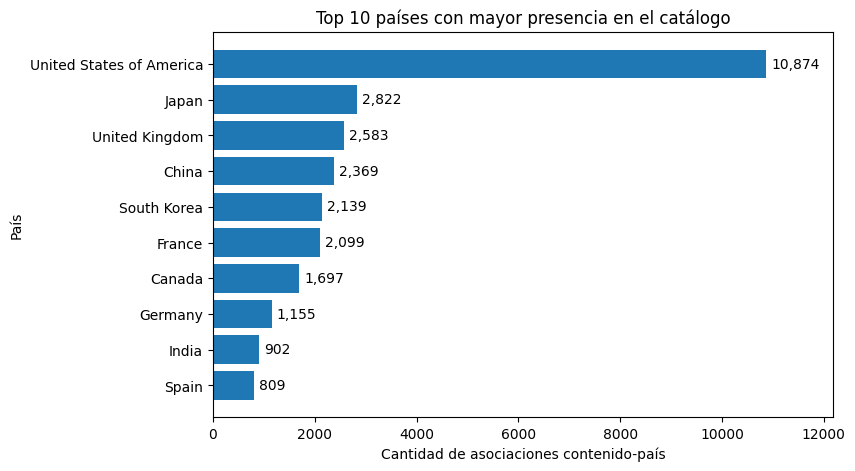

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_10_paises.index[::-1],
    top_10_paises.values[::-1]
)

ax.set_title("Top 10 países con mayor presencia en el catálogo")
ax.set_xlabel("Cantidad de asociaciones contenido-país")
ax.set_ylabel("País")

# Espacio adicional para mostrar los valores
ax.set_xlim(0, top_10_paises.max() * 1.12)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 100,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales para comparar la presencia de
los países con mayor cantidad de asociaciones dentro del catálogo.

Se seleccionaron los 10 países con mayor frecuencia para facilitar la lectura
y reducir la carga visual, considerando que se identificaron 148 categorías
de país diferentes.

Se mantuvo una escala lineal para representar fielmente la diferencia existente
entre Estados Unidos y los demás países. La categoría `Sin información` fue
excluida de la visualización debido a que no representa un país de origen.

**Hallazgo:**

Estados Unidos presenta la mayor participación en el catálogo, con 10.874
asociaciones contenido-país, mostrando una diferencia considerable respecto
del resto de los países.

Japón ocupa el segundo lugar con 2.822 asociaciones, seguido por Reino Unido
con 2.583 y China con 2.369. Corea del Sur y Francia también presentan una
participación relevante, con valores superiores a 2.000 asociaciones.

A partir de Canadá, con 1.697 asociaciones, se observa una nueva disminución
en la presencia de los países dentro del catálogo.

**Interpretación:**

La composición del catálogo muestra una fuerte presencia de contenidos
asociados a Estados Unidos, mientras que los demás países presentan una
participación considerablemente menor.

Sin embargo, una mayor presencia no implica necesariamente un mejor desempeño.
Posteriormente será necesario comparar los países con indicadores como
`popularity`, `vote_average` y `vote_count` para identificar mercados cuyos
contenidos puedan presentar un alto rendimiento aun teniendo una menor
representación en el catálogo.

### 1.4 Revisión de la variable `rating`

Durante la exploración se observó que `rating` contiene valores numéricos
entre 0 y 10, por lo que se revisó su relación con `vote_average` antes de
incorporarla al análisis.

In [ ]:
df[["type", "rating", "vote_average"]].head(20)

,type,rating,vote_average
0,Movie,6.380,6.380
1,Movie,8.369,8.369
2,Movie,7.744,7.744
3,Movie,7.600,7.600
4,Movie,7.800,7.800
5,Movie,8.200,8.200
6,Movie,6.500,6.500
7,Movie,6.800,6.800
8,Movie,6.394,6.394
9,Movie,6.416,6.416


In [ ]:
df.groupby("type")[["rating", "vote_average"]].describe()

rating                                                 vote_average  \
           count      mean       std  min  25%  50%    75%   max        count   
type                                                                            
Movie    16000.0  5.956368  1.754741  0.0  5.6  6.3  6.923  10.0      16000.0   
TV Show  15594.0  5.412947  3.270188  0.0  2.5  6.8  7.800  10.0      15594.0   

                                                         
             mean       std  min  25%  50%    75%   max  
type                                                     
Movie    5.956368  1.754741  0.0  5.6  6.3  6.923  10.0  
TV Show  5.412947  3.270188  0.0  2.5  6.8  7.800  10.0

In [ ]:
# Comprobar si ambas columnas son idénticas en todos los registros
print("¿Son idénticas?:", (df["rating"] == df["vote_average"]).all())
print("Cantidad de valores diferentes:",
      (df["rating"] != df["vote_average"]).sum())

¿Son idénticas?: True
Cantidad de valores diferentes: 0


**Hallazgo:**

La comparación confirmó que `rating` y `vote_average` contienen exactamente
los mismos valores en todos los registros del dataset.

Por lo tanto, `rating` se considera una variable redundante. Para evitar
duplicar información en los análisis posteriores, se utilizará
`vote_average` como variable principal de valoración de los contenidos.

## 2. Desempeño por género

Luego de analizar la composición del catálogo, se evaluará si los géneros con
mayor presencia son también los que presentan mejor desempeño.

Para ello se utilizarán tres indicadores:

- `popularity`: indicador relativo de popularidad.
- `vote_average`: valoración promedio del contenido.
- `vote_count`: cantidad de votos registrados.

Antes de comparar los géneros, se revisará la calidad y distribución de estas
variables para definir qué medidas son más apropiadas para el análisis.

### 2.1 Revisión de la variable de valoración

Antes de calcular valoraciones promedio por género, se revisaron los registros
con `vote_average = 0` para determinar si representan una valoración real o
ausencia de información suficiente.

In [ ]:
df["vote_average"].describe()

,vote_average
count,31594.000000
mean,5.688149
std,2.628933
min,0.000000
25%,5.300000
50%,6.481000
75%,7.300000
max,10.000000


In [ ]:
print(
    "Cantidad de contenidos con vote_average = 0:",
    (df["vote_average"] == 0).sum()
)

print(
    "Porcentaje:",
    round((df["vote_average"] == 0).mean() * 100, 2),
    "%"
)

Cantidad de contenidos con vote_average = 0: 4491
Porcentaje: 14.21 %


In [ ]:
df.loc[
    df["vote_average"] == 0,
    ["title", "type", "vote_average", "vote_count", "popularity"]
].head(20)

,title,type,vote_average,vote_count,popularity
853,Eros Photographer,Movie,0.0,0,4.588
1989,Sonríe,Movie,0.0,0,4.399
2480,YtF,Movie,0.0,0,9.069
2983,SP Woman - Beautiful Sacrifice,Movie,0.0,0,4.903
3256,Torchlighters: The Augustine Story,Movie,0.0,0,14.589
3767,Invisible Hentai Man,Movie,0.0,0,6.475
4581,48 Days,Movie,0.0,0,9.261
4609,An Affair: A Dangerous Sexual Play,Movie,0.0,0,8.870
5120,Isuca: Gokuraku,Movie,0.0,0,24.842
5512,Hipster,Movie,0.0,0,9.412


In [ ]:
df.loc[
    df["vote_average"] == 0,
    "vote_count"
].value_counts().head(10)

,count
vote_count,
0,4474
1,17


**Conclusión metodológica:**

Se identificaron 4.491 contenidos con `vote_average = 0`, equivalentes al
14,21 % del catálogo.

De ellos, 4.474 no registran votos y 17 presentan solamente un voto. Por esta
razón, los valores iguales a cero se interpretarán como contenidos sin una
valoración suficientemente representativa.

Estos registros no serán considerados al calcular la valoración promedio por
género, pero permanecerán disponibles para los análisis de otras variables,
como popularidad.

### 2.2 Revisión de la distribución de popularidad

Antes de comparar la popularidad entre géneros, se revisó la distribución de
`popularity` para determinar si era más apropiado utilizar la media o la
mediana como medida de tendencia central.

In [ ]:
df["popularity"].describe()

,popularity
count,31594.000000
mean,42.326266
std,111.719350
min,2.323000
25%,10.401250
50%,21.867500
75%,41.158250
max,6421.923000


In [ ]:
print("Media de popularidad:", df["popularity"].mean())
print("Mediana de popularidad:", df["popularity"].median())

Media de popularidad: 42.32626625308603
Mediana de popularidad: 21.8675


In [ ]:
df[
    ["title", "type", "popularity", "vote_average", "vote_count"]
].sort_values(
    "popularity",
    ascending=False
).head(10)

,title,type,popularity,vote_average,vote_count
20854,The Late Show with Stephen Colbert,TV Show,6421.923,6.493,288
19882,The Tonight Show Starring Jimmy Fallon,TV Show,4925.253,5.800,321
15000,The Gorge,Movie,3876.006,7.785,1572
17949,Good Mythical Morning,TV Show,3414.466,6.800,67
15001,Flight Risk,Movie,3320.616,6.000,350
23772,Chronicles of the Sun,TV Show,2987.485,6.800,117
29640,Volta por Cima,TV Show,2885.720,5.781,16
29641,She's the One,TV Show,2862.872,8.100,9
14000,Mufasa: The Lion King,Movie,2643.627,7.467,1497
29644,Crazy About You,TV Show,2442.243,5.200,16


**Conclusión metodológica:**

La popularidad presenta una distribución fuertemente asimétrica. La media es
aproximadamente 42,33, mientras que la mediana es 21,89, y existen valores
extremos que superan ampliamente al resto de los contenidos.

Por esta razón, se utilizará la **mediana de popularidad** como indicador
principal para comparar géneros, ya que representa mejor el comportamiento
típico y es menos sensible a valores extremos.

La media se mantendrá únicamente como información complementaria.

### 2.3 Construcción de indicadores de desempeño por género

A partir de las decisiones anteriores, se calcularán para cada género los
siguientes indicadores:

- Cantidad de contenidos.
- Mediana de popularidad.
- Promedio de popularidad como referencia complementaria.
- Total de votos.
- Valoración promedio, considerando solamente contenidos con
  `vote_average > 0`.
- Cantidad de contenidos efectivamente valorados.

In [ ]:
desempeno_genero = (
    df_generos
    .groupby("genre")
    .agg(
        cantidad_contenidos=("show_id", "nunique"),
        popularidad_mediana=("popularity", "median"),
        popularidad_promedio=("popularity", "mean"),
        votos_totales=("vote_count", "sum")
    )
)

In [ ]:
valoracion_genero = (
    df_generos[df_generos["vote_average"] > 0]
    .groupby("genre")
    .agg(
        valoracion_promedio=("vote_average", "mean"),
        contenidos_valorados=("show_id", "nunique")
    )
)

In [ ]:
desempeno_genero = desempeno_genero.join(valoracion_genero)

desempeno_genero

,cantidad_contenidos,popularidad_mediana,popularidad_promedio,votos_totales,valoracion_promedio,contenidos_valorados
genre,,,,,,
Action,5174,23.0125,45.452102,4726252,6.645898,4928
Adventure,3703,28.2780,52.264749,4032304,6.937090,3490
Animation,4000,26.8320,45.473947,1483967,7.181603,3737
Comedy,8983,21.7405,42.612394,3671029,6.657576,8191
Crime,3168,21.3220,40.573622,1819162,6.726720,2970
Documentary,1803,14.9140,28.345769,150512,7.237430,1410
Drama,14571,22.4320,41.548575,5553628,6.754330,12800
Family,2967,25.8190,54.444199,1396847,6.826335,2601
Fantasy,3359,27.4120,45.817357,2365342,6.988168,3147


**Observación inicial:**

La tabla muestra que los géneros con mayor cantidad de contenidos no son
necesariamente los que presentan mayor popularidad o valoración.

Por esta razón, los siguientes análisis compararán estas métricas por separado,
evitando interpretar la cantidad de títulos como sinónimo de desempeño.

### 2.4 Popularidad por género

Para identificar qué géneros presentan una mayor popularidad típica, se
comparará la mediana de `popularity` calculada previamente.

Se considerarán únicamente géneros con al menos 500 contenidos, con el objetivo
de evitar que categorías con muy pocos registros tengan una influencia
desproporcionada en la comparación.

Además, se excluirá la categoría `Sin información`, debido a que no representa
un género de contenido.

Finalmente, se visualizarán los 10 géneros con mayor mediana de popularidad
para facilitar su comparación.

In [ ]:
generos_populares = (
    desempeno_genero[
        (desempeno_genero["cantidad_contenidos"] >= 500) &
        (desempeno_genero.index != "Sin información")
    ]
    .sort_values("popularidad_mediana", ascending=False)
)

top_popularidad = generos_populares.head(10)

top_popularidad[
    ["cantidad_contenidos", "popularidad_mediana"]
]

,cantidad_contenidos,popularidad_mediana
genre,,
Soap,615,88.1160
Talk,643,51.0720
Reality,1589,41.0335
Kids,812,40.9880
Adventure,3703,28.2780
Science Fiction,3363,27.6090
Fantasy,3359,27.4120
Animation,4000,26.8320
Family,2967,25.8190


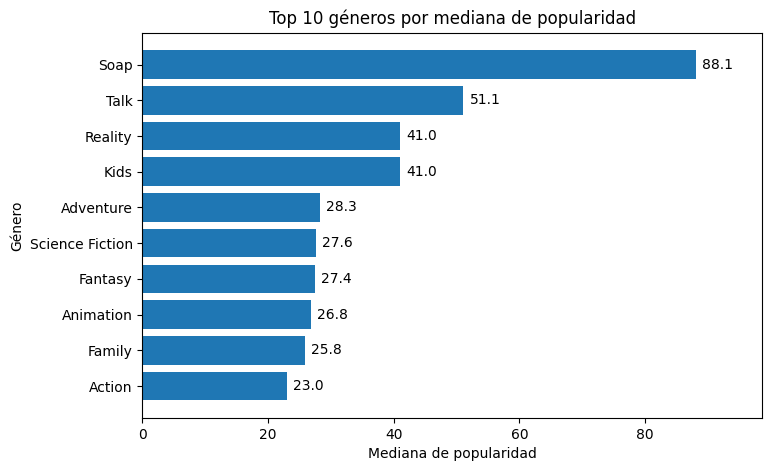

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_popularidad.index[::-1],
    top_popularidad["popularidad_mediana"].values[::-1]
)

ax.set_title("Top 10 géneros por mediana de popularidad")
ax.set_xlabel("Mediana de popularidad")
ax.set_ylabel("Género")

ax.set_xlim(
    0,
    top_popularidad["popularidad_mediana"].max() * 1.12
)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales porque permite comparar de forma
directa la popularidad típica de diferentes géneros y facilita la lectura de
sus nombres.

Los géneros se presentan ordenados según su mediana de popularidad, permitiendo
identificar rápidamente aquellos que presentan los valores más altos.

**Hallazgo:**

Los resultados muestran diferencias importantes en la popularidad típica de
los géneros analizados. `Soap` presenta la mayor mediana de popularidad, con
88,1, seguido por `Talk` con 51,1. `Reality` y `Kids` presentan valores cercanos
a 41.

En contraste, géneros con una presencia mucho mayor dentro del catálogo, como
`Action`, presentan una mediana de popularidad considerablemente menor.

Estos resultados muestran que una mayor cantidad de contenidos disponibles no
implica necesariamente una mayor popularidad típica del género.

**Interpretación:**

El resultado sugiere que algunos géneros con una presencia relativamente menor
en el catálogo pueden alcanzar niveles de popularidad superiores a categorías
con una oferta más amplia.

Esto convierte a géneros como `Soap`, `Talk`, `Reality` y `Kids` en categorías
de interés para análisis posteriores. Sin embargo, la popularidad por sí sola
no es suficiente para recomendar una mayor adquisición de estos contenidos,
por lo que será necesario contrastarla con otros indicadores de desempeño,
como valoración y cantidad de votos.

### 2.5 Valoración por género

En esta sección se analizará qué géneros presentan una mayor valoración
promedio por parte de los usuarios.

Para evitar que géneros con muy pocos contenidos valorados generen resultados
poco representativos, se considerarán únicamente aquellos con al menos 500
contenidos con `vote_average > 0`.

La valoración promedio se calculará utilizando solamente registros con una
valoración válida, según lo definido en la sección 2.1.

In [ ]:
generos_valorados = (
    desempeno_genero[
        desempeno_genero["contenidos_valorados"] >= 500
    ]
    .sort_values("valoracion_promedio", ascending=False)
)

top_valoracion = generos_valorados.head(10)

top_valoracion[
    ["contenidos_valorados", "valoracion_promedio"]
]

,contenidos_valorados,valoracion_promedio
genre,,
Kids,658,7.250912
Documentary,1410,7.237430
Animation,3737,7.181603
Fantasy,3147,6.988168
Adventure,3490,6.937090
Reality,1180,6.870892
Family,2601,6.826335
Science Fiction,3150,6.824931
History,721,6.771319


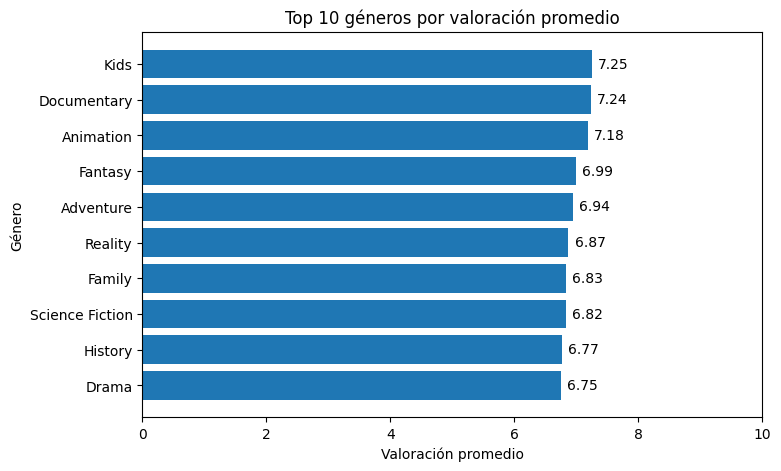

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_valoracion.index[::-1],
    top_valoracion["valoracion_promedio"].values[::-1]
)

ax.set_title("Top 10 géneros por valoración promedio")
ax.set_xlabel("Valoración promedio")
ax.set_ylabel("Género")

# La escala natural de vote_average es de 0 a 10
ax.set_xlim(0, 10)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 0.1,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales para facilitar la comparación
entre las valoraciones promedio de los distintos géneros.

El eje horizontal se mantuvo entre 0 y 10, correspondiente a la escala real
de `vote_average`, con el objetivo de representar las diferencias de manera
proporcional y evitar exagerarlas visualmente.

Se incluyeron únicamente géneros con al menos 500 contenidos valorados para
obtener una comparación basada en una cantidad suficiente de observaciones.

**Interpretación:**

Los resultados muestran que una alta popularidad no necesariamente coincide
con una mayor valoración.

Por ejemplo, `Soap` y `Talk`, que destacaron por su alta mediana de popularidad,
no aparecen entre los géneros con mayor valoración promedio. En cambio,
`Kids` presenta un comportamiento favorable en ambos indicadores, mientras
que `Documentary` y `Animation` destacan principalmente por su valoración.

Esto sugiere que popularidad y valoración representan dimensiones diferentes
del desempeño y deben analizarse de manera complementaria.

### 2.6 Comparación de géneros según tipo de contenido

Los análisis anteriores compararon los géneros considerando películas y series
en conjunto. Sin embargo, algunos géneros pueden estar concentrados
principalmente en uno de los dos tipos de contenido.

Antes de comparar su desempeño, se revisará la cantidad de películas y series
asociadas a cada género.

Para realizar una comparación más equilibrada, se considerarán solamente
géneros que tengan al menos 500 contenidos tanto en `Movie` como en `TV Show`.

In [ ]:
genero_tipo = (
    df_generos
    .groupby(["genre", "type"])
    .agg(
        cantidad_contenidos=("show_id", "nunique"),
        popularidad_mediana=("popularity", "median")
    )
    .reset_index()
)

genero_tipo.head(20)

,genre,type,cantidad_contenidos,popularidad_mediana
0,Action,Movie,3239,14.1040
1,Action,TV Show,1935,38.8130
2,Adventure,Movie,1768,15.8975
3,Adventure,TV Show,1935,38.8130
4,Animation,Movie,1579,13.8010
5,Animation,TV Show,2421,36.0440
6,Comedy,Movie,4533,10.5240
7,Comedy,TV Show,4450,36.5590
8,Crime,Movie,1738,11.8730
9,Crime,TV Show,1430,36.7300


In [ ]:
cantidad_genero_tipo = genero_tipo.pivot(
    index="genre",
    columns="type",
    values="cantidad_contenidos"
).fillna(0)

cantidad_genero_tipo.sort_values(
    by=["Movie", "TV Show"],
    ascending=False
)

type,Movie,TV Show
genre,,
Drama,6910.0,7661.0
Comedy,4533.0,4450.0
Thriller,3769.0,0.0
Action,3239.0,1935.0
Romance,2571.0,0.0
Horror,2425.0,0.0
Adventure,1768.0,1935.0
Crime,1738.0,1430.0
Animation,1579.0,2421.0


In [ ]:
generos_comparables = cantidad_genero_tipo[
    (cantidad_genero_tipo.get("Movie", 0) >= 500) &
    (cantidad_genero_tipo.get("TV Show", 0) >= 500)
]

generos_comparables

type,Movie,TV Show
genre,,
Action,3239.0,1935.0
Adventure,1768.0,1935.0
Animation,1579.0,2421.0
Comedy,4533.0,4450.0
Crime,1738.0,1430.0
Documentary,916.0,887.0
Drama,6910.0,7661.0
Family,1472.0,1495.0
Fantasy,1450.0,1909.0


In [ ]:
generos_comparables

type,Movie,TV Show
genre,,
Action,3239.0,1935.0
Adventure,1768.0,1935.0
Animation,1579.0,2421.0
Comedy,4533.0,4450.0
Crime,1738.0,1430.0
Documentary,916.0,887.0
Drama,6910.0,7661.0
Family,1472.0,1495.0
Fantasy,1450.0,1909.0


**Conclusión metodológica:**

La distribución de los géneros muestra que algunas categorías están presentes
principalmente en un solo tipo de contenido. Por ejemplo, géneros como `Soap`,
`Talk` y `Kids` se concentran en series, mientras que otros como `Horror` y
`Romance` aparecen principalmente en películas.

Para evitar comparaciones entre categorías sin suficiente representación en
ambos formatos, el análisis posterior se limitará a los 11 géneros que cuentan
con al menos 500 películas y 500 series.

#### 2.6.1 Popularidad por género según tipo de contenido

Una vez identificados los géneros con suficiente presencia tanto en películas
como en series, se comparará la mediana de `popularity` entre ambos tipos de
contenido.

El objetivo es determinar si las diferencias observadas previamente entre
géneros pueden estar relacionadas con el tipo de contenido.

Para mantener una comparación equilibrada, se utilizarán únicamente los
géneros con al menos 500 películas y 500 series.

In [ ]:
popularidad_genero_tipo = (
    genero_tipo[
        genero_tipo["genre"].isin(generos_comparables.index)
    ]
    .pivot(
        index="genre",
        columns="type",
        values="popularidad_mediana"
    )
)

popularidad_genero_tipo

type,Movie,TV Show
genre,,
Action,14.1040,38.8130
Adventure,15.8975,38.8130
Animation,13.8010,36.0440
Comedy,10.5240,36.5590
Crime,11.8730,36.7300
Documentary,8.3555,30.3450
Drama,10.5110,36.8830
Family,12.9000,46.1110
Fantasy,14.4650,37.8630


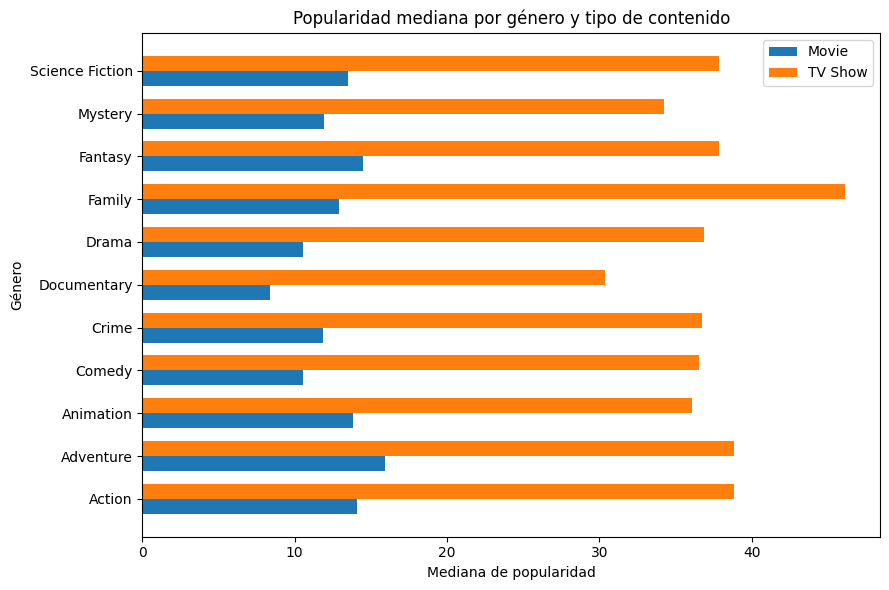

In [ ]:
import numpy as np

generos = popularidad_genero_tipo.index
y = np.arange(len(generos))
alto = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    y - alto/2,
    popularidad_genero_tipo["Movie"],
    height=alto,
    label="Movie"
)

ax.barh(
    y + alto/2,
    popularidad_genero_tipo["TV Show"],
    height=alto,
    label="TV Show"
)

ax.set_yticks(y)
ax.set_yticklabels(generos)

ax.set_title("Popularidad mediana por género y tipo de contenido")
ax.set_xlabel("Mediana de popularidad")
ax.set_ylabel("Género")

ax.legend()

plt.tight_layout()
plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras agrupadas para comparar directamente la
popularidad mediana de películas y series dentro de los mismos géneros.

Esta representación permite identificar si existen diferencias sistemáticas
entre ambos tipos de contenido sin mezclar géneros con distinta composición.

La comparación se limita a géneros con suficiente representación en ambos
formatos, reduciendo el riesgo de interpretar diferencias basadas en categorías
con pocos registros.

In [ ]:
#Código para entender la diferencia entre los resultados en el grafico de tv shows vs movie
#df.groupby("type")["popularity"].describe()

In [ ]:
#df.groupby("type")["popularity"].agg(
#    ["count", "mean", "median", "min", "max"]
#)

**Hallazgo:**

La comparación por tipo de contenido muestra que los `TV Show` presentan
niveles de popularidad considerablemente superiores a las `Movie`.

En el conjunto completo, la mediana de popularidad de las películas es
aproximadamente 10,91, mientras que en las series alcanza 36,19.

Este patrón también se mantiene al comparar géneros equivalentes, donde las
series presentan una mediana de popularidad superior en todos los géneros
analizados.

**Interpretación:**

Las diferencias observadas previamente entre géneros están fuertemente
influenciadas por el tipo de contenido.

Por lo tanto, no sería correcto atribuir la mayor popularidad únicamente al
género. Parte importante del efecto observado se relaciona con que los
contenidos clasificados como `TV Show` presentan valores de `popularity`
sistemáticamente más altos que las películas.

Este resultado deberá considerarse en los análisis posteriores, especialmente
al comparar popularidad entre categorías.

**Consideración metodológica:**

La variable `popularity` corresponde a un índice relativo y no a una medida
directa de reproducciones o audiencia. Dado que su distribución difiere
considerablemente entre `Movie` y `TV Show`, las comparaciones de popularidad
deben interpretarse separando ambos tipos de contenido cuando corresponda.

#### 2.6.2 Valoración por género según tipo de contenido

Luego de observar que los `TV Show` presentan una popularidad considerablemente
superior a las `Movie`, se analizará si esta diferencia también se observa en
la valoración promedio de los contenidos.

Para realizar una comparación equilibrada, se utilizarán los mismos géneros
seleccionados anteriormente, es decir, aquellos con al menos 500 películas y
500 series.

Además, se considerarán solamente contenidos con `vote_average > 0`, según la
decisión metodológica definida previamente.

In [ ]:
valoracion_genero_tipo = (
    df_generos[
        (df_generos["genre"].isin(generos_comparables.index)) &
        (df_generos["vote_average"] > 0)
    ]
    .groupby(["genre", "type"])
    .agg(
        valoracion_promedio=("vote_average", "mean"),
        contenidos_valorados=("show_id", "nunique")
    )
    .reset_index()
)

valoracion_genero_tipo

,genre,type,valoracion_promedio,contenidos_valorados
0,Action,Movie,6.221016,3162
1,Action,TV Show,7.406644,1766
2,Adventure,Movie,6.456097,1724
3,Adventure,TV Show,7.406644,1766
4,Animation,Movie,6.939563,1534
5,Animation,TV Show,7.350064,2203
6,Comedy,Movie,6.297602,4372
7,Comedy,TV Show,7.069675,3819
8,Crime,Movie,6.350693,1692
9,Crime,TV Show,7.224559,1278


In [ ]:
valoracion_genero_tipo_pivot = valoracion_genero_tipo.pivot(
    index="genre",
    columns="type",
    values="valoracion_promedio"
)

valoracion_genero_tipo_pivot

type,Movie,TV Show
genre,,
Action,6.221016,7.406644
Adventure,6.456097,7.406644
Animation,6.939563,7.350064
Comedy,6.297602,7.069675
Crime,6.350693,7.224559
Documentary,7.102307,7.407635
Drama,6.463138,7.062806
Family,6.682830,7.000495
Fantasy,6.484712,7.395796


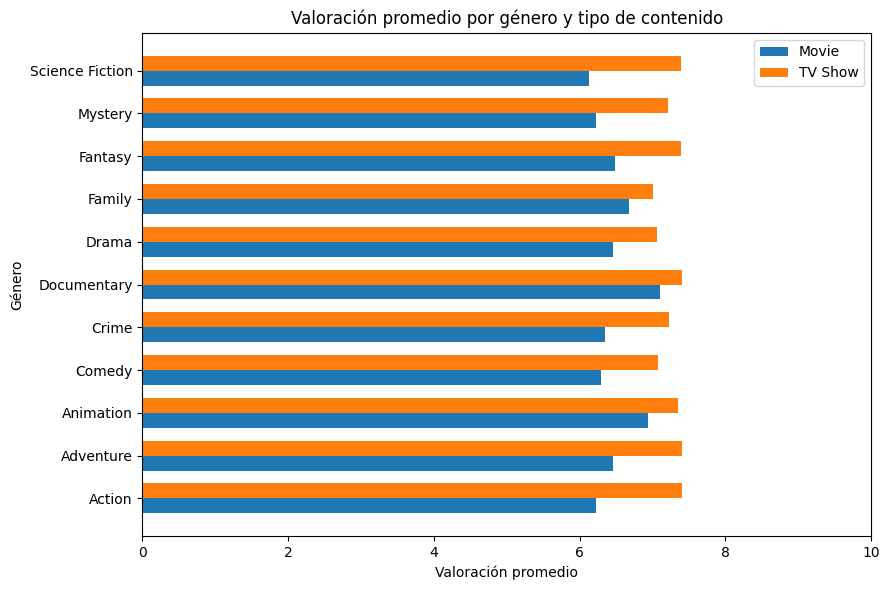

In [ ]:
generos = valoracion_genero_tipo_pivot.index
y = np.arange(len(generos))
alto = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    y - alto/2,
    valoracion_genero_tipo_pivot["Movie"],
    height=alto,
    label="Movie"
)

ax.barh(
    y + alto/2,
    valoracion_genero_tipo_pivot["TV Show"],
    height=alto,
    label="TV Show"
)

ax.set_yticks(y)
ax.set_yticklabels(generos)

ax.set_title("Valoración promedio por género y tipo de contenido")
ax.set_xlabel("Valoración promedio")
ax.set_ylabel("Género")

# Mantener la escala original de vote_average
ax.set_xlim(0, 10)

ax.legend()

plt.tight_layout()
plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras agrupadas para comparar directamente la
valoración promedio de películas y series dentro de los mismos géneros.

El eje horizontal se mantiene entre 0 y 10, correspondiente a la escala
original de `vote_average`, evitando exagerar visualmente diferencias que
puedan ser pequeñas.

La comparación se limita a géneros con suficiente representación en ambos
tipos de contenido y considera únicamente contenidos con una valoración válida.

Antes de interpretar las diferencias de valoración entre géneros, se revisará
si existe una diferencia general entre películas y series.

Esto permitirá determinar si el patrón observado corresponde específicamente
a los géneros o si forma parte de una diferencia general asociada al tipo de
contenido.

In [ ]:
valoracion_por_tipo = (
    df[df["vote_average"] > 0]
    .groupby("type")["vote_average"]
    .agg(["count", "mean", "median", "std"])
)

valoracion_por_tipo

,count,mean,median,std
type,,,,
Movie,15101,6.310965,6.4,1.012144
TV Show,12002,7.032952,7.2,1.581329


In [ ]:
df[df["vote_average"] > 0].groupby("type")["vote_average"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,15101.0,6.310965,1.012144,1.0,5.731,6.4,7.0,10.0
TV Show,12002.0,7.032952,1.581329,0.5,6.300,7.2,8.0,10.0


**Hallazgo:**

Los `TV Show` presentan valoraciones superiores a las `Movie` tanto a nivel
general como dentro de los géneros comparables.

En el conjunto completo de contenidos con valoración válida, las películas
presentan una valoración promedio cercana a 6,31 y una mediana de 6,4,
mientras que las series alcanzan una media aproximada de 7,03 y una mediana
de 7,2.

Este patrón también se observa al comparar los mismos géneros entre ambos
tipos de contenido.

**Interpretación:**

A diferencia de la popularidad, donde las diferencias entre películas y series
son muy amplias, en la valoración las diferencias son más moderadas.

Aun así, los resultados indican que el tipo de contenido está asociado tanto
con `popularity` como con `vote_average`, por lo que las comparaciones entre
géneros deben considerar si se trata de películas o series.

Esto evita atribuir al género diferencias que pueden estar relacionadas con
el tipo de contenido.



---

### Síntesis del Bloque 2

El análisis mostró que la cantidad de contenidos de un género no implica
necesariamente un mejor desempeño.

La popularidad y la valoración entregan señales diferentes: algunos géneros
con menor presencia presentan una popularidad típica elevada, mientras que las
diferencias de valoración entre géneros son más acotadas.

Además, se identificó que el tipo de contenido influye de manera importante en
la interpretación de estas métricas. Los `TV Show` presentan valores de
`popularity` considerablemente mayores que las `Movie` y también una
valoración promedio algo superior.

Por esta razón, los análisis posteriores considerarán el tipo de contenido
cuando sea necesario para evitar atribuir al género diferencias que pueden
estar asociadas al formato.

---



## 3. Relación entre popularidad y valoración

En este bloque se analizará la relación entre la popularidad de los contenidos
y la valoración entregada por los usuarios.

El objetivo es determinar si los contenidos con mayor popularidad también
tienden a presentar mejores valoraciones, e identificar posibles casos de
contenidos con alta valoración pero menor popularidad.

Para el análisis de `vote_average` se considerarán únicamente registros con
valoraciones válidas, excluyendo los valores iguales a cero según lo definido
previamente.

In [ ]:
df_valorado = df[df["vote_average"] > 0].copy()

correlacion = df_valorado[
    ["popularity", "vote_average"]
].corr()

correlacion

,popularity,vote_average
popularity,1.000000,0.055084
vote_average,0.055084,1.000000


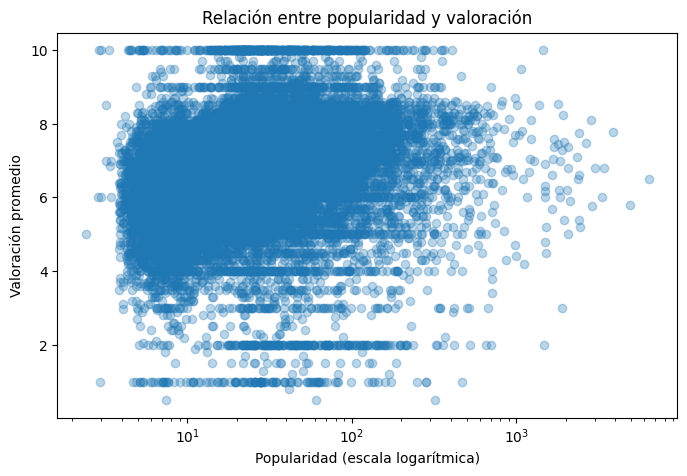

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_valorado["popularity"],
    df_valorado["vote_average"],
    alpha=0.3
)

ax.set_xscale("log")

ax.set_title("Relación entre popularidad y valoración")
ax.set_xlabel("Popularidad (escala logarítmica)")
ax.set_ylabel("Valoración promedio")

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de dispersión porque ambas variables son numéricas y
se busca observar la relación entre ellas.

Debido a la presencia de valores extremos en `popularity`, se aplicó una
escala logarítmica en el eje X para mejorar la visualización sin eliminar
observaciones.

**Hallazgo:**

La correlación entre `popularity` y `vote_average` es aproximadamente 0,055,
por lo que no se observa una relación lineal relevante entre ambas variables.

Esto indica que los contenidos más populares no necesariamente son los mejor
valorados. Se observan contenidos con valoraciones altas y niveles relativamente
bajos de popularidad, así como contenidos muy populares con valoraciones
intermedias.

**Interpretación:**

La popularidad y la valoración representan dimensiones distintas del desempeño.
Por esta razón, las decisiones de adquisición o posicionamiento no deberían
basarse únicamente en uno de estos indicadores, sino considerar ambos de forma
complementaria.

## 4. Características del contenido y desempeño

Inicialmente se consideró analizar la relación entre la duración del contenido
y su popularidad.

Sin embargo, durante la revisión de la variable `duration` se identificó que
la información no permite realizar este análisis de forma válida.

En las películas, la duración aparece como `Sin información`. En las series,
los 15.594 registros disponibles presentan exactamente `1 Seasons`, sin
variación entre contenidos.

Por lo tanto, la variable `duration` no aporta información suficiente para
evaluar su relación con el desempeño.

In [ ]:
df[["type", "duration"]].head(20)

,type,duration
0,Movie,Sin información
1,Movie,Sin información
2,Movie,Sin información
3,Movie,Sin información
4,Movie,Sin información
5,Movie,Sin información
6,Movie,Sin información
7,Movie,Sin información
8,Movie,Sin información
9,Movie,Sin información


In [ ]:
df.groupby("type")["duration"].apply(
    lambda x: x.dropna().sample(min(10, len(x.dropna())))
)

type          
Movie    6770     Sin información
         5936     Sin información
         11898    Sin información
         1414     Sin información
         3455     Sin información
         7352     Sin información
         9741     Sin información
         5784     Sin información
         8842     Sin información
         68       Sin información
TV Show  29107          1 Seasons
         24276          1 Seasons
         21955          1 Seasons
         17821          1 Seasons
         24185          1 Seasons
         17589          1 Seasons
         29432          1 Seasons
         16477          1 Seasons
         31113          1 Seasons
         20635          1 Seasons
Name: duration, dtype: object

### 4.1 Revisión de la variable `duration`

La variable `duration` no se encuentra disponible de forma homogénea para
todos los contenidos.

En las películas, la duración aparece principalmente como `Sin información`,
mientras que en las series se expresa mediante el número de temporadas.

Por esta razón, no es posible realizar una comparación general de duración
entre películas y series.

In [ ]:
tv_shows["temporadas"].describe()

,temporadas
count,15594.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
tv_shows["temporadas"].value_counts().sort_index()

,count
temporadas,
1.0,15594


**Conclusión del bloque:**

No es posible analizar la relación entre duración y popularidad con el dataset
disponible, ya que la variable `duration` carece de información útil para
películas y no presenta variabilidad en las series.

Por esta razón, este análisis no se incorporará a las visualizaciones finales.

## 5. Evolución temporal del catálogo

En este bloque se analizará la evolución temporal de los contenidos disponibles
en StreamView Analytics.

El objetivo es observar cómo se distribuyen los contenidos según su año de
estreno y su año de incorporación al catálogo, e identificar si existen cambios
relevantes en el volumen o desempeño a lo largo del tiempo.

Para ello se utilizarán principalmente las variables `release_year`,
`date_added_year` y `popularity`.

In [ ]:
df[["release_year", "date_added_year"]].describe()

,release_year,date_added_year
count,31594.000000,31594.000000
mean,2017.508293,2017.508293
std,4.610627,4.610627
min,2010.000000,2010.000000
25%,2014.000000,2014.000000
50%,2018.000000,2018.000000
75%,2022.000000,2022.000000
max,2025.000000,2025.000000


In [ ]:
print("Año mínimo de estreno:", df["release_year"].min())
print("Año máximo de estreno:", df["release_year"].max())

print("Año mínimo de incorporación:", df["date_added_year"].min())
print("Año máximo de incorporación:", df["date_added_year"].max())

Año mínimo de estreno: 2010
Año máximo de estreno: 2025
Año mínimo de incorporación: 2010
Año máximo de incorporación: 2025


In [ ]:
contenidos_por_estreno = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

contenidos_por_estreno.tail(20)

,count
release_year,
2010,1972
2011,1977
2012,1966
2013,1967
2014,1972
2015,1969
2016,1980
2017,1969
2018,1964


In [ ]:
contenidos_por_incorporacion = (
    df["date_added_year"]
    .value_counts()
    .sort_index()
)

contenidos_por_incorporacion

,count
date_added_year,
2010,1972
2011,1977
2012,1966
2013,1967
2014,1972
2015,1969
2016,1980
2017,1969
2018,1964


In [ ]:
(df["release_year"] == df["date_added_year"]).value_counts()

,count
True,31594


In [ ]:
print(
    "Filas con años diferentes:",
    (df["release_year"] != df["date_added_year"]).sum()
)

Filas con años diferentes: 0


### 5.1 Revisión de variables temporales

Antes de analizar la evolución temporal, se compararon las variables
`release_year` y `date_added_year`.

Se comprobó que ambas columnas contienen exactamente el mismo año en los
31.594 registros del dataset, sin existir ninguna observación con valores
diferentes.

Por esta razón, utilizar ambas variables produciría análisis redundantes.
Para el análisis temporal se utilizará únicamente `release_year`.

In [ ]:
evolucion_anual = (
    df
    .groupby("release_year")
    .agg(
        cantidad_contenidos=("show_id", "nunique"),
        popularidad_mediana=("popularity", "median")
    )
    .reset_index()
)

evolucion_anual

,release_year,cantidad_contenidos,popularidad_mediana
0,2010,1972,16.6260
1,2011,1977,19.4940
2,2012,1966,19.2755
3,2013,1967,20.6800
4,2014,1972,21.1670
5,2015,1969,23.5050
6,2016,1980,25.0980
7,2017,1969,24.3410
8,2018,1964,24.7990
9,2019,1970,26.4105


In [ ]:
valoracion_anual = (
    df[df["vote_average"] > 0]
    .groupby("release_year")
    .agg(
        valoracion_promedio=("vote_average", "mean")
    )
    .reset_index()
)

evolucion_anual = evolucion_anual.merge(
    valoracion_anual,
    on="release_year",
    how="left"
)

evolucion_anual

,release_year,cantidad_contenidos,popularidad_mediana,valoracion_promedio
0,2010,1972,16.6260,6.408727
1,2011,1977,19.4940,6.416804
2,2012,1966,19.2755,6.434973
3,2013,1967,20.6800,6.506217
4,2014,1972,21.1670,6.541072
5,2015,1969,23.5050,6.506434
6,2016,1980,25.0980,6.545138
7,2017,1969,24.3410,6.620238
8,2018,1964,24.7990,6.673804
9,2019,1970,26.4105,6.767738


### 5.2 Evolución del desempeño según año de estreno

La cantidad de contenidos disponibles por año se mantiene relativamente
estable durante todo el período analizado, por lo que no se realizará una
visualización específica de esta variable.

El análisis se concentrará en observar cómo evolucionan la popularidad mediana
y la valoración promedio de los contenidos según su año de estreno.

Estas métricas se visualizarán por separado debido a que utilizan escalas
diferentes.

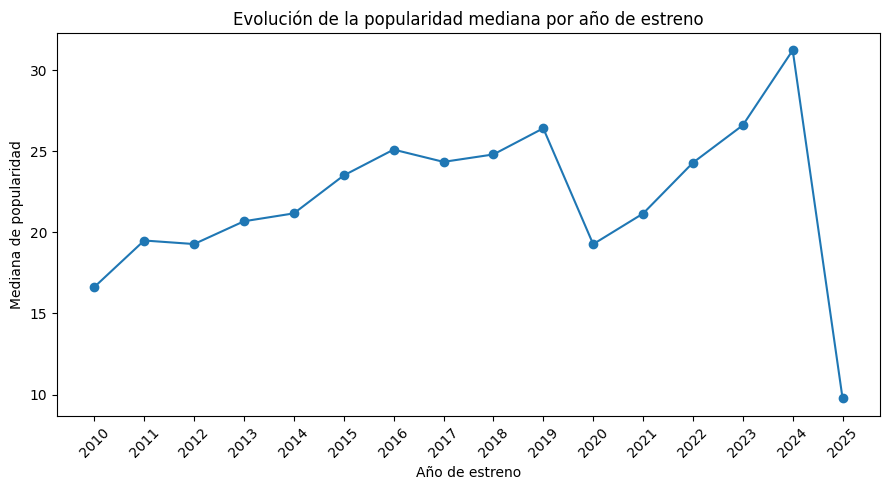

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    evolucion_anual["release_year"],
    evolucion_anual["popularidad_mediana"],
    marker="o"
)

ax.set_title("Evolución de la popularidad mediana por año de estreno")
ax.set_xlabel("Año de estreno")
ax.set_ylabel("Mediana de popularidad")

ax.set_xticks(evolucion_anual["release_year"])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

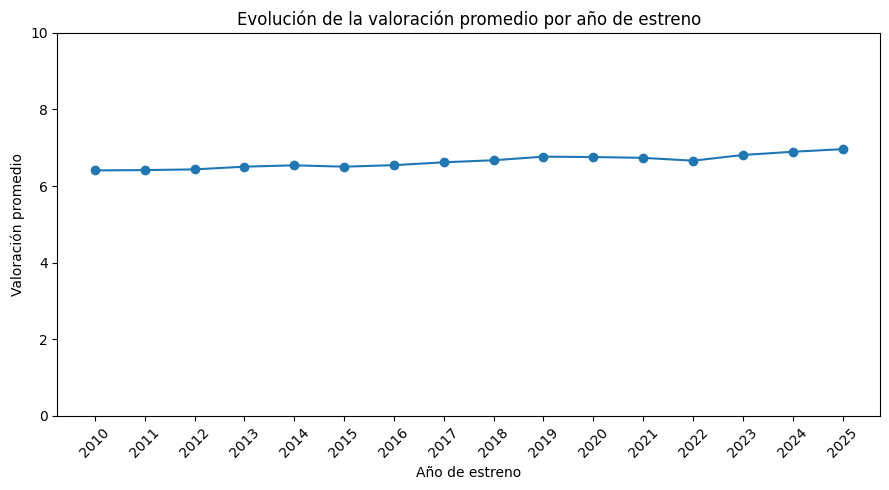

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    evolucion_anual["release_year"],
    evolucion_anual["valoracion_promedio"],
    marker="o"
)

ax.set_title("Evolución de la valoración promedio por año de estreno")
ax.set_xlabel("Año de estreno")
ax.set_ylabel("Valoración promedio")

ax.set_ylim(0, 10)

ax.set_xticks(evolucion_anual["release_year"])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Justificación de las visualizaciones:**

Se utilizaron gráficos de líneas porque las variables se analizan a lo largo
de una secuencia temporal, permitiendo observar cambios y tendencias entre
años consecutivos.

La popularidad y la valoración se presentan en gráficos separados debido a
que corresponden a métricas con escalas diferentes, evitando utilizar un doble
eje que podría dificultar la comparación.

En la valoración se conserva la escala original de 0 a 10 para representar
las diferencias de manera proporcional.

**Hallazgo:**

Entre 2010 y 2024 se observa una tendencia general de aumento en la popularidad
mediana de los contenidos, aunque con fluctuaciones durante el período. La
popularidad alcanza su mayor valor en 2024, con una mediana aproximada de 31,22.

En 2025 se produce una caída considerable de la popularidad mediana hasta
aproximadamente 9,76, constituyendo un comportamiento atípico respecto de los
años anteriores.

La valoración promedio presenta un comportamiento mucho más estable. Aumenta
gradualmente desde aproximadamente 6,41 en 2010 hasta valores cercanos a 6,90
en los años más recientes, sin presentar variaciones de la magnitud observada
en popularidad.

**Interpretación:**

Los resultados muestran que la popularidad y la valoración también presentan
comportamientos diferentes a lo largo del tiempo.

Mientras la popularidad muestra mayores fluctuaciones y una tendencia creciente
hasta 2024, la valoración se mantiene relativamente estable y presenta solo
un aumento gradual.

La fuerte disminución de popularidad observada en 2025 no está acompañada por
una disminución equivalente en la valoración. Con la información disponible
no es posible determinar la causa de este comportamiento, por lo que debe
interpretarse con precaución.

### Síntesis del Bloque 5

El análisis temporal muestra que el volumen de contenidos por año se mantiene
prácticamente constante, mientras que su desempeño presenta cambios.

La popularidad muestra una tendencia general creciente hasta 2024 y mayores
fluctuaciones entre años, mientras que la valoración permanece relativamente
estable.

Además, `release_year` y `date_added_year` contienen exactamente la misma
información en el dataset, por lo que se utilizó únicamente `release_year`
para evitar análisis redundantes.

## 6. Análisis financiero de películas

En este bloque se analizará el comportamiento financiero de las películas
mediante las variables `budget`, `revenue` y `roi`.

El objetivo es determinar si mayores presupuestos se relacionan con mayores
ingresos y si un mayor nivel de inversión implica necesariamente un mejor
retorno.

Debido a que estas variables financieras no se encuentran disponibles para
las series, el análisis se realizará únicamente sobre contenidos de tipo
`Movie`.

In [ ]:
peliculas = df[df["type"] == "Movie"].copy()

peliculas[
    ["title", "budget", "revenue", "roi"]
].head(20)

,title,budget,revenue,roi
0,Shrek Forever After,165000000.0,7.526009e+08,4.561217
1,Inception,160000000.0,8.390306e+08,5.243941
2,Harry Potter and the Deathly Hallows: Part 1,250000000.0,9.543059e+08,3.817223
3,Tangled,260000000.0,5.924617e+08,2.278699
4,How to Train Your Dragon,165000000.0,4.948795e+08,2.999270
5,Shutter Island,80000000.0,2.948042e+08,3.685052
6,The Karate Kid,40000000.0,3.591260e+08,8.978151
7,Iron Man 2,200000000.0,6.239333e+08,3.119667
8,Grown Ups,80000000.0,2.714302e+08,3.392877
9,Room in Rome,NaN,8.442810e+05,NaN


In [ ]:
peliculas[
    ["budget", "revenue", "roi"]
].describe()

,budget,revenue,roi
count,4.847000e+03,5.645000e+03,3.540000e+03
mean,2.893928e+07,6.933733e+07,7.815457e+02
std,4.708018e+07,1.795958e+08,4.155657e+04
min,1.000000e+00,2.000000e+00,7.800000e-06
25%,3.898000e+06,1.100000e+06,5.213043e-01
50%,1.050000e+07,8.555008e+06,1.700033e+00
75%,3.000000e+07,4.915834e+07,3.760963e+00
max,4.600000e+08,2.799439e+09,2.456760e+06


In [ ]:
print("Total de películas:", len(peliculas))

print(
    "Películas con budget informado:",
    peliculas["budget"].notna().sum()
)

print(
    "Películas con revenue informado:",
    peliculas["revenue"].notna().sum()
)

print(
    "Películas con ROI informado:",
    peliculas["roi"].notna().sum()
)

Total de películas: 16000
Películas con budget informado: 4847
Películas con revenue informado: 5645
Películas con ROI informado: 3540


In [ ]:
print(
    "Budget = 0:",
    (peliculas["budget"] == 0).sum()
)

print(
    "Revenue = 0:",
    (peliculas["revenue"] == 0).sum()
)

Budget = 0: 0
Revenue = 0: 0


### 6.1 Revisión de las variables financieras

Las variables financieras se encuentran disponibles únicamente para una parte
de las películas del catálogo.

De un total de 16.000 películas:

- 4.847 presentan información de presupuesto.
- 5.645 presentan información de ingresos.
- 3.540 cuentan con un valor de ROI calculado.

No se identificaron presupuestos ni ingresos iguales a cero.

La distribución del ROI presenta valores extremos muy elevados: mientras la
mediana es cercana a 1,70, la media supera ampliamente este valor debido a la
presencia de outliers.

Por esta razón, el análisis financiero se realizará únicamente sobre películas
con información disponible y se interpretará el ROI con precaución.

### 6.2 Relación entre presupuesto e ingresos

Se analizará si las películas con mayores presupuestos también tienden a
generar mayores ingresos.

Para ello se considerarán únicamente los registros que cuentan con información
válida tanto de `budget` como de `revenue`.

In [ ]:
finanzas = peliculas[
    peliculas["budget"].notna() &
    peliculas["revenue"].notna()
].copy()

print("Películas con budget y revenue disponibles:", len(finanzas))

Películas con budget y revenue disponibles: 3540


In [ ]:
finanzas[
    ["budget", "revenue"]
].corr()

,budget,revenue
budget,1.000000,0.747865
revenue,0.747865,1.000000


In [ ]:
finanzas[
    ["budget", "revenue"]
].describe()

,budget,revenue
count,3.540000e+03,3.540000e+03
mean,3.558214e+07,1.037772e+08
std,5.118602e+07,2.178201e+08
min,1.000000e+00,2.000000e+00
25%,5.903050e+06,4.207730e+06
50%,1.500000e+07,2.380000e+07
75%,4.000000e+07,9.509302e+07
max,4.600000e+08,2.799439e+09


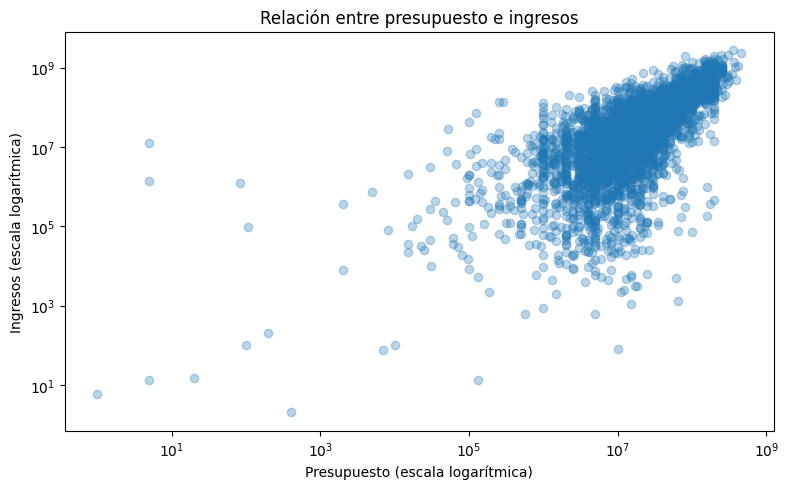

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    finanzas["budget"],
    finanzas["revenue"],
    alpha=0.3
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Relación entre presupuesto e ingresos")
ax.set_xlabel("Presupuesto (escala logarítmica)")
ax.set_ylabel("Ingresos (escala logarítmica)")

plt.tight_layout()
plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de dispersión debido a que se busca analizar la relación
entre dos variables numéricas: presupuesto e ingresos.

Debido al amplio rango de valores presente en ambas variables, se aplicó una
escala logarítmica en ambos ejes. Esto permite visualizar mejor la distribución
de las películas sin eliminar las producciones con presupuestos o ingresos
elevados.

La correlación entre `budget` y `revenue` es aproximadamente 0,748, lo que
indica una relación positiva considerable entre ambas variables.

**Hallazgo:**

Se observa una relación positiva entre el presupuesto y los ingresos de las
películas. La correlación entre ambas variables es aproximadamente 0,748,
lo que indica que las producciones con mayores presupuestos tienden a generar
mayores ingresos.

La visualización también muestra dispersión entre los datos, por lo que un
mayor presupuesto no garantiza necesariamente un determinado nivel de ingresos.

**Interpretación:**

El presupuesto aparece como un factor relacionado con la capacidad de generar
ingresos, pero no permite explicar por sí solo el desempeño financiero de una
película.

Por esta razón, invertir más recursos puede estar asociado a mayores ingresos,
pero esto no implica necesariamente una mayor eficiencia o rentabilidad de la
inversión.

### 6.3 Relación entre presupuesto y retorno de inversión

Luego de identificar una relación positiva entre presupuesto e ingresos, se
analizará si las películas con mayores presupuestos también presentan un mayor
retorno de inversión (`roi`).

Este análisis permitirá distinguir entre generar mayores ingresos y obtener
un mayor retorno en relación con la inversión realizada.

In [ ]:
finanzas_roi = peliculas[
    peliculas["budget"].notna() &
    peliculas["roi"].notna()
].copy()

print(
    "Películas con budget y ROI disponibles:",
    len(finanzas_roi)
)

Películas con budget y ROI disponibles: 3540


In [ ]:
finanzas_roi[
    ["budget", "roi"]
].corr()

,budget,roi
budget,1.000000,-0.013028
roi,-0.013028,1.000000


In [ ]:
finanzas_roi["roi"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

,roi
count,3.540000e+03
mean,7.815457e+02
std,4.155657e+04
min,7.800000e-06
50%,1.700033e+00
90%,7.200285e+00
95%,1.181960e+01
99%,3.733730e+01
max,2.456760e+06


In [ ]:
print(
    "Películas con ROI menor que 0:",
    (finanzas_roi["roi"] < 0).sum()
)

print(
    "Películas con ROI entre 0 y 10:",
    ((finanzas_roi["roi"] >= 0) &
     (finanzas_roi["roi"] <= 10)).sum()
)

print(
    "Películas con ROI mayor que 10:",
    (finanzas_roi["roi"] > 10).sum()
)

Películas con ROI menor que 0: 0
Películas con ROI entre 0 y 10: 3319
Películas con ROI mayor que 10: 221


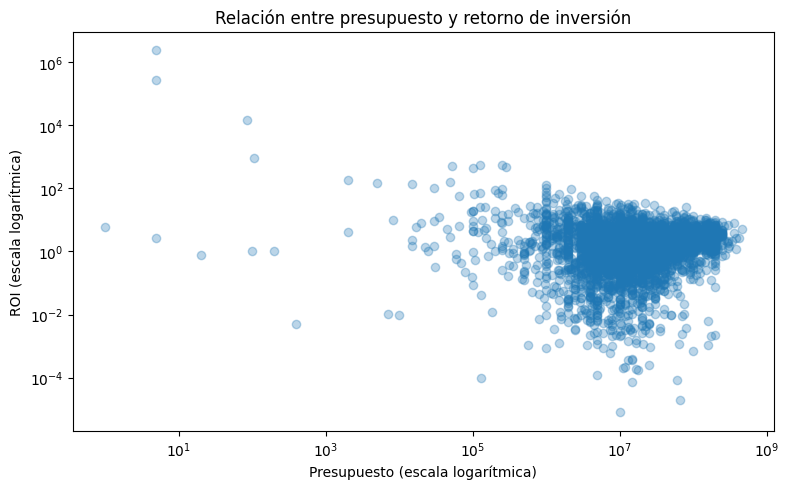

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    finanzas_roi["budget"],
    finanzas_roi["roi"],
    alpha=0.3
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Relación entre presupuesto y retorno de inversión")
ax.set_xlabel("Presupuesto (escala logarítmica)")
ax.set_ylabel("ROI (escala logarítmica)")

plt.tight_layout()
plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de dispersión para analizar la relación entre el
presupuesto y el retorno de inversión de las películas.

Debido a que ambas variables presentan rangos amplios y el ROI contiene
valores extremos muy elevados, se utilizaron escalas logarítmicas en ambos
ejes. Esto permite representar todas las observaciones sin eliminar los
valores extremos y facilita la visualización de la concentración principal
de los datos.

**Hallazgo:**

La correlación entre `budget` y `roi` es aproximadamente -0,013, un valor
prácticamente igual a cero. Esto indica que no se observa una relación lineal
relevante entre el presupuesto de una película y su retorno de inversión.

La visualización confirma este resultado, mostrando una alta dispersión del
ROI para distintos niveles de presupuesto. También se observan algunos valores
extremos de retorno, principalmente asociados a presupuestos relativamente
bajos.

**Interpretación:**

Un mayor presupuesto no implica necesariamente un mayor retorno relativo de
la inversión.

Esto complementa el análisis anterior: aunque los mayores presupuestos tienden
a estar asociados con mayores ingresos, esa relación no se mantiene al evaluar
el retorno obtenido respecto de la inversión realizada.

Por lo tanto, generar mayores ingresos y lograr una mayor eficiencia financiera
representan dimensiones diferentes del desempeño.

### Síntesis del Bloque 6

El análisis financiero muestra una relación positiva considerable entre
presupuesto e ingresos, con una correlación aproximada de 0,748. Esto indica
que las películas con mayores presupuestos tienden a generar mayores ingresos.

Sin embargo, la relación entre presupuesto y ROI es prácticamente inexistente,
con una correlación cercana a cero (-0,013). Por lo tanto, un mayor nivel de
inversión no garantiza un mayor retorno relativo.

Estos resultados sugieren que el presupuesto debe analizarse junto con
indicadores de retorno, ya que mayores ingresos no necesariamente representan
una inversión más eficiente.

Los resultados financieros deben interpretarse considerando que estas
variables están disponibles únicamente para una parte de las películas del
dataset.

## Hallazgos clave del análisis exploratorio

A partir del análisis realizado se identificaron los siguientes hallazgos:

1. **El catálogo presenta una distribución equilibrada entre películas y series.**
   Las películas representan aproximadamente el 50,64 % del catálogo y las
   series el 49,36 %, por lo que no existe una predominancia importante de uno
   de los dos tipos en términos de cantidad.

2. **La oferta se concentra principalmente en algunos géneros y países.**
   `Drama` y `Comedy` presentan la mayor cantidad de asociaciones dentro del
   catálogo, mientras que Estados Unidos concentra ampliamente la mayor
   presencia por país de origen.

3. **Una mayor presencia dentro del catálogo no implica necesariamente un mejor desempeño.**
   Algunos géneros con menor cantidad de contenidos presentan una popularidad
   típica superior a géneros mucho más representados. Esto indica que la
   cantidad de títulos disponibles no debe interpretarse como sinónimo de
   popularidad.

4. **El tipo de contenido influye de manera importante en las métricas de desempeño.**
   Los `TV Show` presentan valores de `popularity` considerablemente superiores
   a las `Movie`, y también muestran una valoración promedio algo mayor.
   Por esta razón, las comparaciones de desempeño deben considerar el tipo de
   contenido para evitar atribuir únicamente al género diferencias que pueden
   estar relacionadas con el formato.

5. **Popularidad y valoración representan dimensiones diferentes del desempeño.**
   La correlación entre `popularity` y `vote_average` es aproximadamente 0,055,
   por lo que no se observa una relación lineal relevante entre ambas variables.
   Un contenido más popular no necesariamente presenta una mejor valoración.

6. **El desempeño presenta comportamientos distintos a lo largo del tiempo.**
   La popularidad mediana muestra una tendencia general creciente entre 2010 y
   2024, aunque con fluctuaciones, mientras que la valoración promedio se
   mantiene mucho más estable y aumenta de forma gradual. En 2025 se observa una
   caída marcada de popularidad que no está acompañada por una disminución
   equivalente en la valoración.

7. **Un mayor presupuesto se relaciona con mayores ingresos, pero no con un mayor ROI.**
   La correlación entre `budget` y `revenue` es aproximadamente 0,748, mostrando
   una relación positiva considerable. En cambio, la correlación entre `budget`
   y `roi` es cercana a cero (-0,013), por lo que invertir más no implica
   necesariamente obtener un mayor retorno relativo.

### Conclusión del EDA

Los resultados muestran que el desempeño del catálogo no puede explicarse a
partir de una única variable. La cantidad de contenidos, la popularidad, la
valoración, el tipo de contenido y los resultados financieros entregan señales
diferentes y complementarias.

Estos hallazgos servirán como base para seleccionar las visualizaciones más
relevantes y construir una narrativa orientada a la Gerencia de Contenidos y
Adquisición, evitando sobrecargar la solución final con análisis que no aporten
directamente a la toma de decisiones.